In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# 1. Load your cleaned data
df = pd.read_csv('Cleaned_Maritime_Data.csv')

In [9]:
# 2. Define Features (X) and Target (y)
# Adjust these list names if your columns differ slightly
features = ['Avg_Age', 'Avg_Size_GT', 'Avg_Cargo_DWT', 'Avg_TEU', 'Year', 'Semester']
categorical_features = ['Ship_Type', 'Region']
X = df[features + categorical_features]
y = df['Median_Port_Time']

In [10]:
# 3. Create a Preprocessing Pipeline
# This handles the text-to-number conversion for categorical variables
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'  # Keep numerical features as they are
)

In [11]:
# 4. Define the full Model Pipeline
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

In [12]:
# 5. Split and Train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [13]:
# 6. Evaluate
predictions = model.predict(X_test)
print(f"Mean Absolute Error: {mean_absolute_error(y_test, predictions):.2f} days")
print(f"R-squared Score: {r2_score(y_test, predictions):.2f}")

Mean Absolute Error: 0.09 days
R-squared Score: 0.93


C:\Users\my\AppData\Local\Temp\ipykernel_5624\1005939044.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='viridis')


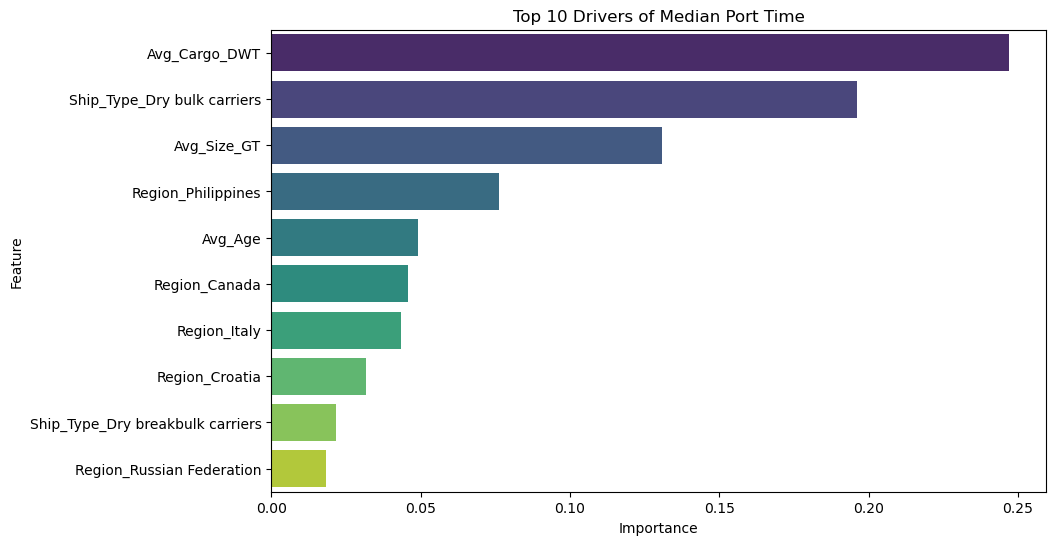

In [14]:
# 7. Visualization: Feature Importance
# Extracting feature names after OneHotEncoding
ohe = model.named_steps['preprocessor'].named_transformers_['cat']
ohe_feature_names = ohe.get_feature_names_out(categorical_features)
all_feature_names = list(ohe_feature_names) + features

importances = model.named_steps['regressor'].feature_importances_
importance_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='viridis')
plt.title('Top 10 Drivers of Median Port Time')
plt.show()